<center>
<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:
           font-size:150%;
           letter-spacing:0.5px">

<h2 style="padding: 10px;
              color:black;">Titanic Survivor Predictions
    
</h2>
</div>
    
</center>

![](https://images.news18.com/ibnlive/uploads/2022/04/titanic.-16496673314x3.jpg)

## Overview
- The RMS Titanic sank in the early morning hours of 15 April 1912 in the North Atlantic Ocean, four days into her maiden voyage from Southampton to New York City. The largest ocean liner in service at the time, Titanic had an estimated 2,224 people on board when she struck an iceberg at around 23:40 (ship's time) on Sunday, 14 April 1912. 

- Her sinking two hours and forty minutes later at 02:20 (ship's time; 05:18 GMT) on Monday, 15 April, resulted in the deaths of more than 1,500 people, making it one of the deadliest peacetime maritime disasters in history.

> It is now our job to predict if a passenger survived the sinking of the Titanic or not. For each row in the test set, you must predict a 0 (Not survived) or 1 value (Survived) for the `Survived` column which is out output column.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style("darkgrid")
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (22,5)

In [2]:
import random
from sklearn.preprocessing import OneHotEncoder, StandardScaler, scale, MinMaxScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score,  accuracy_score, precision_score, confusion_matrix 
from sklearn.metrics import classification_report, roc_curve, auc 
from sklearn.impute import KNNImputer
from sklearn import decomposition 
from imblearn.over_sampling  import RandomOverSampler

#Deep Learning Libraries
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

In [3]:
train_df = pd.read_csv('../input/titanic/train.csv')
test_df = pd.read_csv('../input/titanic/test.csv')
submission = pd.read_csv('../input/titanic/gender_submission.csv')

In [4]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [8]:
#Stats about the independent Variable
train_df[['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']]. describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Exploratory Data Analysis 
Exploratory Data Analysis refers to the critical process of performing initial investigations on data so as to discover patterns,to spot anomalies,to test hypothesis and to check assumptions with the help of summary statistics and graphical representations.

![](https://miro.medium.com/max/1400/1*03D9umtAeoGnFXYH-Ycm8A.png)

For the ease of analysis we have separated the data into two data frames based on the `Survived` column value. 

In [9]:
Survived_df = train_df[train_df.Survived.eq(1)]
Not_Survived_df = train_df[train_df.Survived.eq(0)]

In [10]:
Survived_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
...,...,...,...,...,...,...,...,...,...,...,...,...
875,876,1,3,"Najib, Miss. Adele Kiamie ""Jane""",female,15.0,0,0,2667,7.2250,NaN,C
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
880,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S


In [11]:
Not_Survived_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [12]:
Survived_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 342 entries, 1 to 889
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  342 non-null    int64  
 1   Survived     342 non-null    int64  
 2   Pclass       342 non-null    int64  
 3   Name         342 non-null    object 
 4   Sex          342 non-null    object 
 5   Age          290 non-null    float64
 6   SibSp        342 non-null    int64  
 7   Parch        342 non-null    int64  
 8   Ticket       342 non-null    object 
 9   Fare         342 non-null    float64
 10  Cabin        136 non-null    object 
 11  Embarked     340 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 34.7+ KB


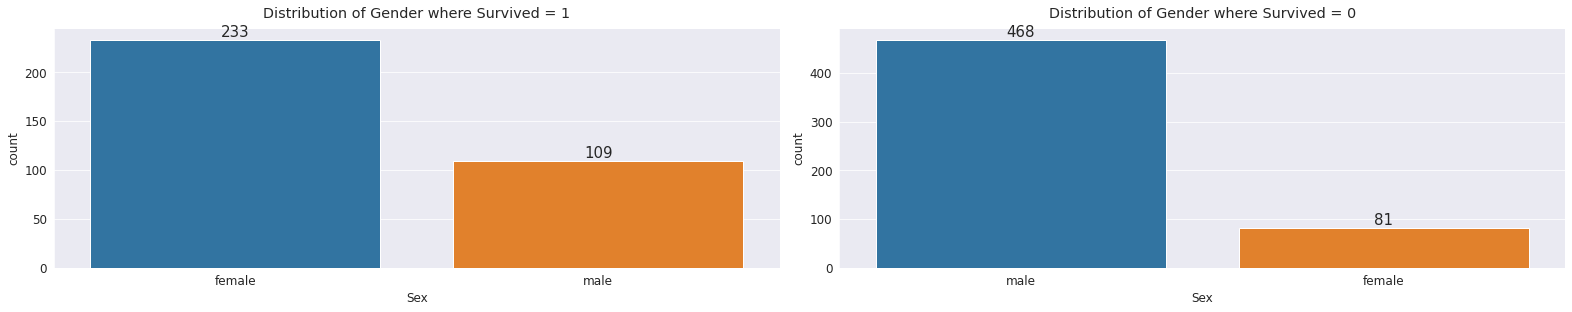

In [13]:
a = 3  # number of rows
b = 2  # number of columns
c = 1  # initialize plot counter

#Set the figure size of the plot
fig = plt.figure(figsize=(22,12))
        
dataframes =[Survived_df, Not_Survived_df]
for i in dataframes:
    plt.subplot(a, b, c)
    ax = sns.countplot(i['Sex'])
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.title(f'Distribution of Gender where Survived = {i.Survived.unique()[0]}', y=1.02)
    for bar in ax.patches:
        ax.annotate(format(bar.get_height(), '.0f'),(bar.get_x() + bar.get_width() / 2,bar.get_height()), 
                 ha='center', va='center',size=15, xytext=(0, 8),textcoords='offset points')
    c = c + 1

#Adjust the layout of the plot
plt.tight_layout()
#Show the plot
plt.show()

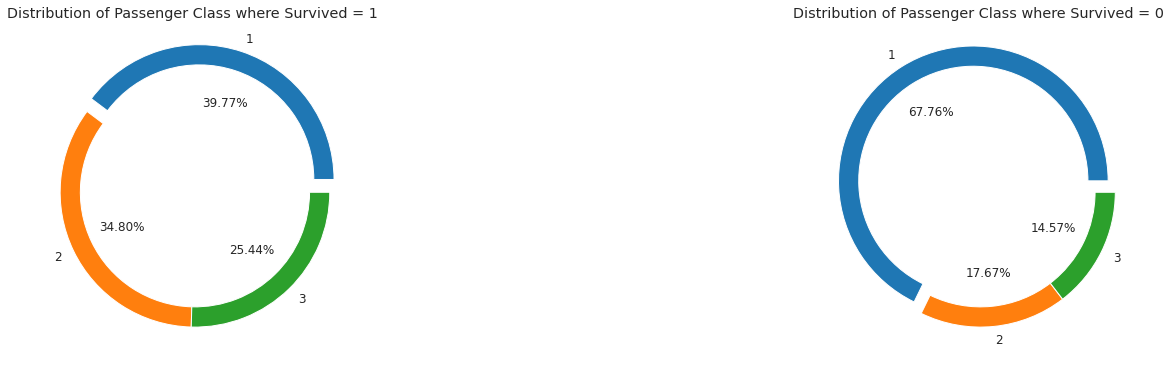

In [14]:
a = 3  # number of rows
b = 2  # number of columns
c = 1  # initialize plot counter

#Set the figure size of the plot
fig = plt.figure(figsize=(22,15))

dataframes =[Survived_df, Not_Survived_df]
for i in dataframes:
    plt.subplot(a, b, c)
    
    list1 = list(i['Pclass'].value_counts().values)
    max_val=max(list1)
    max_index=list1.index(max_val)
    explode = [0.1 if num==max_index else 0 for (num,item) in enumerate(list1)]
    plt.pie(i['Pclass'].value_counts(), labels=['1', '2', '3'], autopct='%1.2f%%', 
            explode=explode,  wedgeprops=dict(width=0.15))
    plt.title(f'Distribution of Passenger Class where Survived = {i.Survived.unique()[0]} ')
    c = c + 1

#Adjust the layout of the plot
plt.tight_layout()
#Show the plot
plt.show()

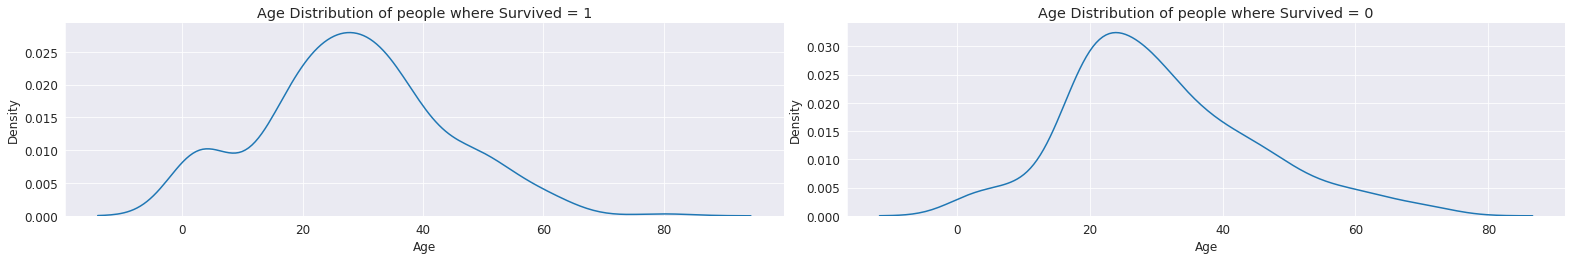

In [15]:
dataframes =[Survived_df, Not_Survived_df]

a = 3  # number of rows
b = 2  # number of columns
c = 1  # initialize plot counter

#Set the figure size of the plot
fig = plt.figure(figsize=(22,10))

dataframes =[Survived_df, Not_Survived_df]
for i in dataframes:
    plt.subplot(a, b, c)
    sns.kdeplot(i['Age'])
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.title(f'Age Distribution of people where Survived = {i.Survived.unique()[0]}')
    c = c + 1

#Adjust the layout of the plot
plt.tight_layout()
#Show the plot
plt.show()

In [16]:
corr = train_df.corr()
corr

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


Above is the correlation heatmap that tells us which features have positive correlation amongst them which can help us choose the features when preparing a prediction model.

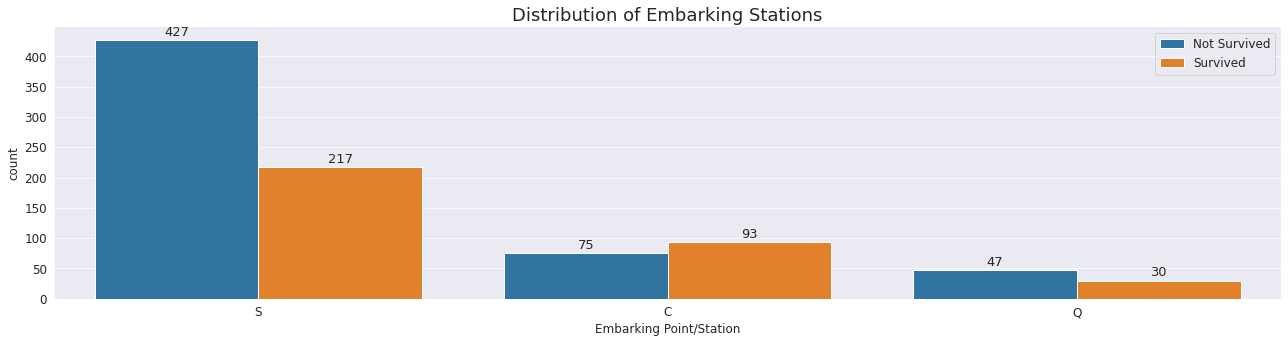

In [17]:
ax = sns.countplot(data=train_df, x='Embarked', hue='Survived')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
for bar in ax.patches:
        ax.annotate(format(bar.get_height(), '.0f'),(bar.get_x() + bar.get_width() / 2,bar.get_height()), 
                 ha='center', va='center',size=13, xytext=(0, 8),textcoords='offset points')
plt.title('Distribution of Embarking Stations', fontsize=18)
plt.xlabel('Embarking Point/Station')
plt.legend(['Not Survived', 'Survived'], loc='upper right')
plt.show()

From the S class of `Embarked` column, there are highest survivors and deaths.

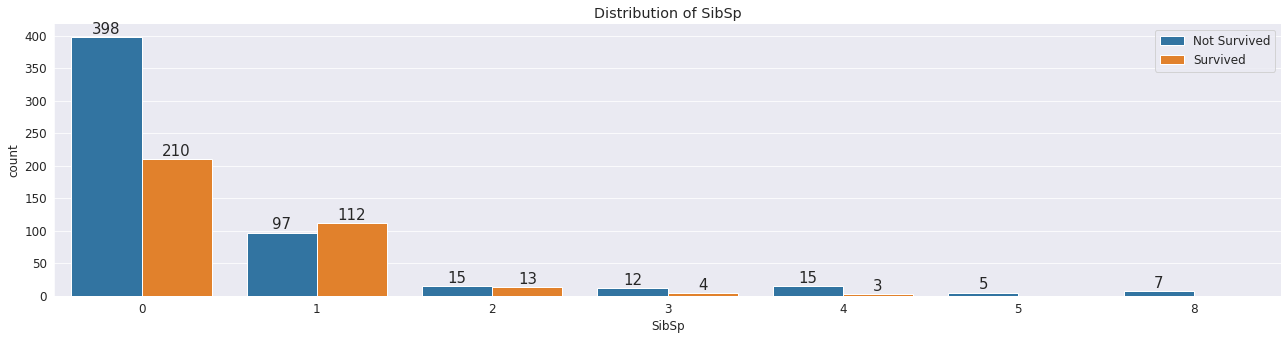

In [18]:
ax = sns.countplot(data=train_df, x='SibSp', hue='Survived')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
for bar in ax.patches:
        ax.annotate(format(bar.get_height(), '.0f'),(bar.get_x() + bar.get_width() / 2,bar.get_height()), 
                 ha='center', va='center',size=15, xytext=(0, 8),textcoords='offset points')
plt.title('Distribution of SibSp')
plt.xlabel('SibSp')
plt.legend(['Not Survived', 'Survived'], loc='upper right')
plt.show()

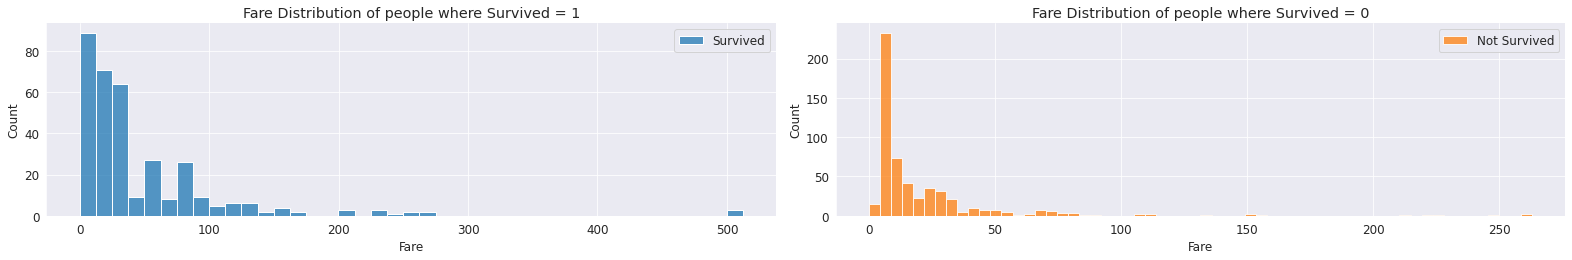

In [19]:
labels = ['Not Survived', 'Survived']
colors = plt.rcParams["axes.prop_cycle"]()
a = 3  # number of rows
b = 2  # number of columns
c = 1  # initialize plot counter

#Set the figure size of the plot
fig = plt.figure(figsize=(22,10))

for i in dataframes:
    color = next(colors)["color"]
    plt.subplot(a, b, c)
    sns.histplot(i['Fare'], color=color)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.title(f'Fare Distribution of people where Survived = {i.Survived.unique()[0]}')
    for j in labels:
        if i.Survived.unique()==0:
            legend = labels[0]
        else:
            legend = labels[1]
    plt.legend([legend])
    c = c + 1

#Adjust the layout of the plot
plt.tight_layout()
#Show the plot
plt.show()

The chance of a person not surviving was far more than the person who paid more. Something to also remember, there would be lesser people as we go up the fare ladder.

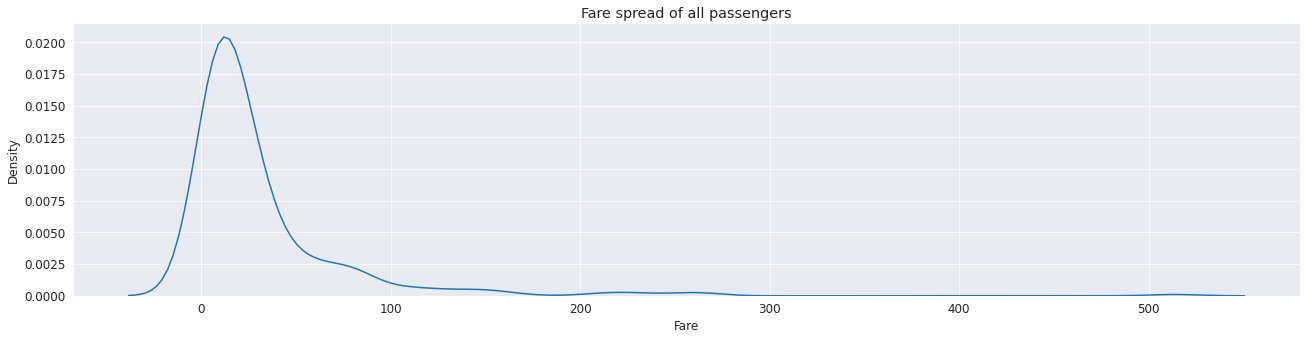

In [20]:
sns.kdeplot(train_df['Fare'])
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.title('Fare spread of all passengers')
plt.show()

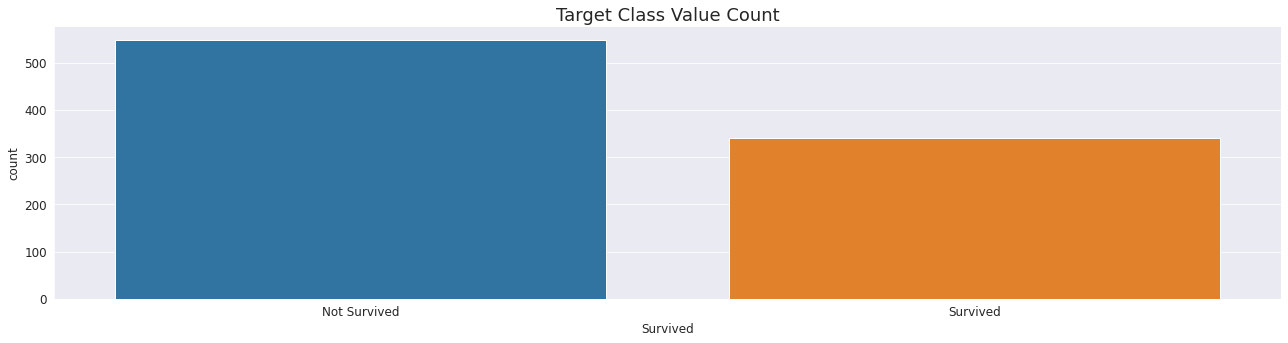

In [21]:
sns.countplot(train_df['Survived'])
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.title('Target Class Value Count', fontsize=18)
plt.xticks([0,1], ['Not Survived', 'Survived'])
plt.show()

<center> <h2> Data Pre-processing </h2> </center> 

In this section, we are gonna be cleaning up our data and getting it prepared for the model. We would be dealing with the missing values, categorical data and dropping any other unnecessary columns in the dataset.

<center>
<img src="https://149695847.v2.pressablecdn.com/wp-content/uploads/2018/01/data-cleaning.png">
</center>

In [22]:
test_df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [23]:
Test_df = test_df.copy()
inputs_df = train_df.copy()

In [24]:
print(f'The columns in the test dataframe are {Test_df.columns}')

The columns in the test dataframe are Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [25]:
print(f'The columns in the Inputs dataframe are {inputs_df.columns}')

The columns in the Inputs dataframe are Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [26]:
#Dropping Columns since they wouldn't necessarily add to the better performance of the model
inputs_df.drop(['Name', 'Ticket', 'PassengerId'], axis=1, inplace = True)
Test_df.drop(['Name', 'Ticket', 'PassengerId'], axis=1, inplace = True)

In [27]:
#Assigning the target values and storing the data in a dataframe
target_col = inputs_df.columns[1]
targets_df = inputs_df['Survived']

In [28]:
inputs_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,NaN,S
887,1,1,female,19.0,0,0,30.0000,B42,S
888,0,3,female,NaN,1,2,23.4500,NaN,S
889,1,1,male,26.0,0,0,30.0000,C148,C


In [29]:
categorical_cols = inputs_df.select_dtypes(include=['object']).columns.tolist()
categorical_cols1 = Test_df.select_dtypes(include=['object']).columns.tolist()

<center> <h3> OneHotEncoding </h3> </center> 

For categorical variables where no such ordinal relationship exists, the integer encoding is not enough. In fact, using this encoding and allowing the model to assume a natural ordering between categories may result in poor performance or unexpected results (predictions halfway between categories).

In this case, a one-hot encoding can be applied to the integer representation. This is where the integer encoded variable is removed and a new binary variable is added for each unique integer value.

![](https://i.imgur.com/n8GuiOO.png)

In [30]:
encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
encoder.fit(inputs_df[categorical_cols])
encoded_cols = list(encoder.get_feature_names(categorical_cols))
inputs_df[encoded_cols] = encoder.transform(inputs_df[categorical_cols])

In [31]:
encoded_cols1 = list(encoder.get_feature_names(categorical_cols1))
Test_df[encoded_cols1] = encoder.transform(Test_df[categorical_cols1])

<center> <h3> Imputation </h3> </center> 

Imputation is a machine learning technique used to deal with missing data. It is the process of replacing missing values with estimated values. The various strategies of imputing are:

1. **Mean/Mode/Median Imputation**: Replacing missing values with the mean, mode, or median of the rest of the data.

2. **K-Nearest Neighbour (KNN) Imputation**: Replacing missing values using the values from the K-nearest neighbours.

3. **Multiple Imputation**: Replacing missing values with multiple values drawn from a distribution.

4. **Hot Deck Imputation**: Replacing missing values with values from similar cases.

5. **Regression Imputation**: Replacing missing values with the predicted values from a linear regression model.


![](https://vitalflux.com/wp-content/uploads/2018/10/Missing-Data-Imputation-Techniques.png)

We will be using KNN Imputation to fill the missing values:- 

- KNN Imputation is a form of data imputation that uses the values of the k-nearest neighbors of a given data point to fill in missing values. 

- It works by finding the k-nearest neighbors of a given data point, based on the Euclidean distance metric or some other distance metric, and then using the values of those neighbors to fill in the missing value. 

- This method of imputation is commonly used in machine learning algorithms and can help improve the accuracy of the results.

In [32]:
imputer = KNNImputer(n_neighbors=2)

In [33]:
#filling the Inouts_df missing values with KNN Imputation
inputs_df.Age = np.squeeze(imputer.fit_transform(np.expand_dims(inputs_df.Age, axis=1)))
#filling the Inputs Data missing values with mean
inputs_df['Age'].isna().sum()

0

In [34]:
#filling the Test set missing values with KNN Imputation
Test_df.Age = np.squeeze(imputer.fit_transform(np.expand_dims(Test_df.Age, axis=1)))
Test_df['Age'].isna().sum()

0

<center> <h3>  Dropping Columns </h3> </center> 


- We are dropping those columns here that have been `OneHotEncoded` since having unnecessary columns in the model can lead to the Curse of dimensionality and the model may not be as explainable to the relevant stakeholders.

- In machine learning problems that involve learning a "state-of-nature" from a finite number of data samples in a high-dimensional feature space with each feature having a range of possible values, typically an enormous amount of training data is required to ensure that there are several samples with each combination of values. 

In an abstract sense, as the number of features or dimensions grows, the amount of data we need to generalize accurately grows exponentially.

In [35]:
#Dropping Unnecessary Columns
inputs_df.drop(['Sex', 'Cabin', 'Embarked', 'Survived'], axis=1, inplace = True)
Test_df.drop(['Sex', 'Cabin', 'Embarked'], axis=1, inplace = True)

<center>
<img src="https://miro.medium.com/max/1100/1*7xf9e1EaoK5n05izIFBouA.webp">
</center>

In [36]:
#Oversampling the data based on minority class
oversample = RandomOverSampler(sampling_strategy='minority')
inputs_df, targets_df = oversample.fit_resample(inputs_df, targets_df)

In [37]:
print(f'The shape of the dataframe after oversampling is {inputs_df.shape}')

The shape of the dataframe after oversampling is (1098, 159)


Now that we are done resolving the imbalanced class issue. Lets go to scaling the data. There are several types of scaling in machine learning which is listed below:-

1. **Normalization**: Normalization is a technique used to scale a dataset so that all values are within a similar range, usually between 0 and 1, or -1 and 1. Typically, this is done by subtracting the mean of the dataset from the value of each element and then dividing the result by the standard deviation.

2. **Standardization**: Standardization is a technique used to scale a dataset so that its mean is 0, and its standard deviation is 1. This is done by subtracting the mean from each value and dividing it by the standard deviation.

3. **Min-Max Scaling**: Min-Max scaling is a technique used to scale a dataset so that the values lie within a defined range. Typically, this range is between 0 and 1, or -1 and 1. Min-Max scaling involves subtracting the minimum value from each element, and then dividing that result by the difference between the maximum and minimum values.

4. **Robust Scaling**: Robust scaling is a technique used to scale a dataset so that it is robust to outliers. It works by subtracting the median of the dataset from each element and then dividing it by the interquartile range. This ensures that the scaling takes into account the outliers, so they don't affect the overall scaling.

In [38]:
#Scaling Input data
X = scale(inputs_df)

<center> <h2>  Principal Component Analysis (PCA) </h2> </center> 


- Principal Component Analysis is a way to reduce the number of variables while maintaining the majority of the important information. It transforms a number of variables that may be correlated into a smaller number of uncorrelated variables, known as principal components.

- The main objective of PCA is to simplify your model features into fewer components to help visualize patterns in your data and to help your model run faster. Using PCA also reduces the chance of overfitting your model by eliminating features with high correlation.

<center>
<img src="https://qph.cf2.quoracdn.net/main-qimg-9a0de236de04a06bcdb6161861457f39.webp">
</center>

In [39]:
pca = decomposition.PCA(0.90)
pca.fit(X)

PCA(n_components=0.9)

In [40]:
pcascores = pca.transform(X)
scores_df = pd.DataFrame(pcascores)
target = pd.Series(targets_df, name='target')
result_df = pd.concat([scores_df, target], axis=1)
result_df.head()

,0,1,2,3,4,5,6,7,8,9,...,126,127,128,129,130,131,132,133,134,target
0,-1.823845,0.360874,0.212976,-0.064678,0.516480,-0.111155,0.033667,-0.287808,-0.332944,0.010668,...,1.844485e-15,1.786219e-15,-3.214793e-16,1.075664e-15,4.334998e-17,-1.089405e-15,-1.546534e-15,5.874113e-16,-9.984655e-16,0
1,4.169566,-0.583068,-2.030544,-0.342016,-1.301174,-0.633212,-1.001960,-0.307910,-2.729998,-0.078557,...,1.155645e-11,2.247486e-11,-2.353830e-12,2.613542e-12,9.127758e-13,-5.867190e-12,-3.202541e-12,1.857753e-12,3.164077e-12,1
2,-0.845920,-1.303598,0.153516,0.441127,-0.994712,-0.086986,0.213639,-0.658423,0.043637,-0.031668,...,-3.470708e-15,-1.427932e-16,1.255384e-15,2.671609e-15,1.295820e-15,6.245020e-16,-2.420217e-16,-1.001595e-15,2.956382e-16,1
3,2.190312,-0.580981,2.257659,0.194065,-1.874526,-0.197526,0.189929,0.647469,-2.899721,-0.173176,...,-3.891958e-13,-1.950667e-12,-2.070603e-14,3.386120e-13,-3.755071e-13,-5.653366e-13,-7.848780e-13,-4.943154e-13,-4.879880e-13,1
4,-1.654839,0.902181,0.183334,0.155416,-0.023318,0.126903,0.001404,-0.504817,0.111140,0.008696,...,-8.616838e-16,-5.258755e-17,7.766007e-16,3.032432e-15,8.274450e-16,-2.886578e-15,-2.483284e-15,-7.101619e-16,-1.223980e-15,0


In [41]:
print('X shape after the PCA is',pcascores.shape)

X shape after the PCA is (1098, 135)


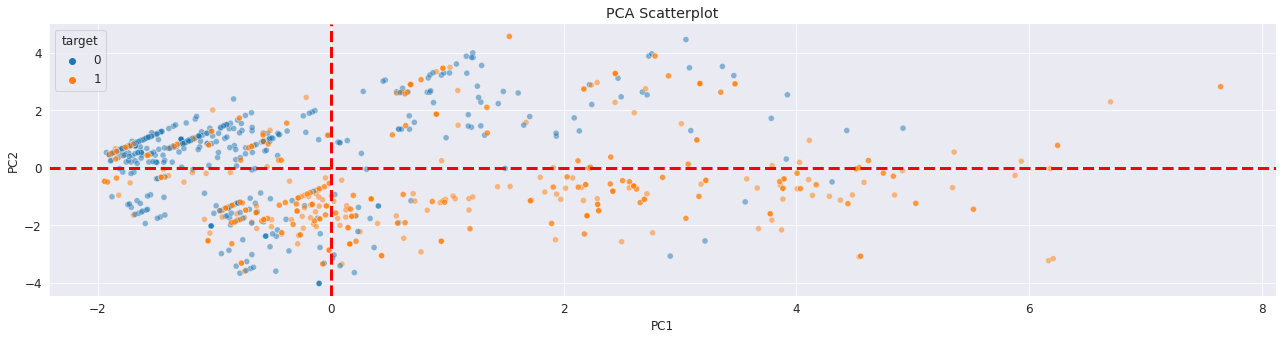

In [42]:
sns.scatterplot(data=result_df, x=0, y=1, hue='target', alpha=0.5)
plt.title('PCA Scatterplot')

plt.axhline(0, linestyle='--', lw=3, zorder=1, color='red')
plt.axvline(0, linestyle='--', lw=3, zorder=1, color='red')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [43]:
for i in range(1,pca.explained_variance_ratio_.shape[0]):
    if np.cumsum(pca.explained_variance_ratio_)[i]*100<91 and i%20==0:
        variance = round(np.cumsum(pca.explained_variance_ratio_)[i]*100,4)
        print('At',i,'features, cumulative sum of explained variance is', variance)
variance = round(np.cumsum(pca.explained_variance_ratio_)[i]*100,4)
print('At',i,'features, cumulative sum of explained variance is', variance)

At 20 features, cumulative sum of explained variance is 18.1978
At 40 features, cumulative sum of explained variance is 30.8142
At 60 features, cumulative sum of explained variance is 43.4165
At 80 features, cumulative sum of explained variance is 56.0157
At 100 features, cumulative sum of explained variance is 68.6059
At 120 features, cumulative sum of explained variance is 81.196
At 134 features, cumulative sum of explained variance is 90.0091


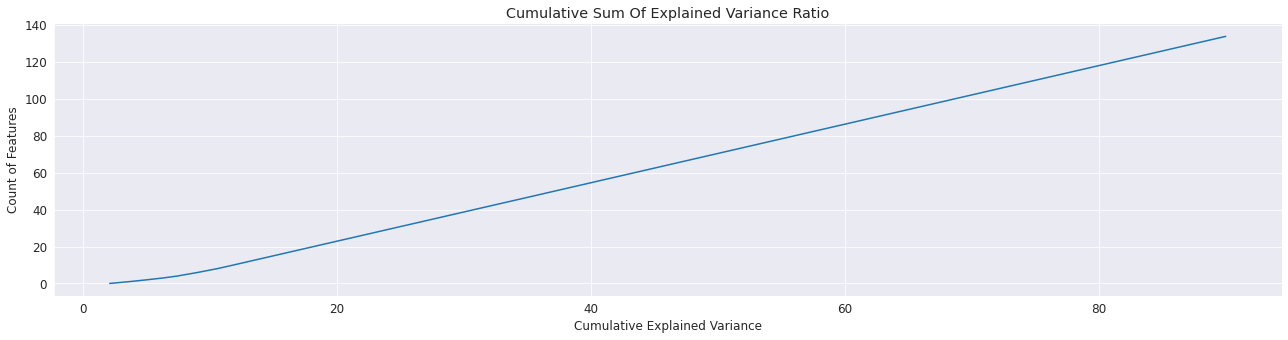

In [44]:
plt.plot(np.around(np.cumsum(pca.explained_variance_ratio_)*100,2), range(pca.explained_variance_ratio_.shape[0]))
plt.title('Cumulative Sum Of Explained Variance Ratio')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.xlabel('Cumulative Explained Variance')
plt.ylabel('Count of Features')
plt.show()

In [45]:
scaler = MinMaxScaler()
pcascores = scaler.fit_transform(pcascores)
X =  pcascores
y = np.array(targets_df.values)

<center>
<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:white;
           font-size:110%;
           letter-spacing:0.5px">

<h2 style="padding: 10px;
              color:black;">Building a Custom Logistic Regression Class from scratch
    
</h2>
</div>
    
</center>

In [46]:
class Logistic_Regression():
    """Logistic Regression using Gradient Descent to classify binary classess
    
    Returns
    ------
    
    coefficient and the slope values
    
    Parameters
    ------
    fit - model training method that returns the weight and the biases of the model. 
          Implements the exponential decay of learning rate
    
    score - Scores the model based on precision by taking the y_true and y_pred values
    
    predict - takes X_test, passess them through the sigmoid and converts the probability into either 0 or 1, 
               threshold value being 0.5
    
    plot - Plots a misclassification plot by checking which values are incorrectly misclassified by the model 
           and returns a countplot
    
    """
    def __init__(self):
        self.w = None
        self.b = None

    def _update_params(self, probs, y_train, X_train,learning_rate= 0.01 ):
        db = np.sum( probs - y_train)/ len(y_train)
        self.b = self.b - (learning_rate * db)
        dw = np.dot((probs - y_train), X_train)/ len(y_train)
        self.w = self.w - (learning_rate * dw)
        return self.b, self.w
    
    def sigmoid(self, X_train):
        Z = self.b + np.matmul(X_train,self.w)
        probs =  (1.0 / (1 + np.exp(-Z)))
        return probs    

    def cost(self, X_train, y_train):
        probs = self.sigmoid(X_train)
        cost = - np.sum((np.dot(y_train.T,np.log(probs)))+ (np.dot((1-y_train).T,np.log(1-probs)))) / ( len(y_train))
        return cost, probs
    
    def EarlyStopping(self, loss):
        for i in range(1, len(loss)):
            yield (loss[i-1], loss[i])
    
    def fit(self, X_train, y_train, epochs =1000, learning_rate=0.01, batchsize=100, *args, **kwargs):
        import random
        decay_rate =  0.95 
        self.b = random.randint(0, 1)
        self.w = np.random.rand(X_train.shape[1])
        Cost =[]
        for i in range(epochs):
            batches = round(X_train.shape[0]//batchsize)
            for j in range(batches):
                
                if i==0:
                    #Updating the params at certain intervals in an epoch
                    if j % batchsize==0:
                        learning_rate = learning_rate
                        cost, probs =  self.cost(X_train, y_train)
                        
                        #Updating params
                        self.b, self.w = self._update_params(probs, y_train, X_train, learning_rate = learning_rate)
                        
                        #Setting the seed
                        np.random.seed(10)

                        #Shuffling the data before the next iteration
                        np.random.shuffle([X_train, y_train])

                    else:
                        #Not training the Parameters if the above condition is not met
                        self.w = self.w
                        self.b = self.b

                else: #Decaying the Learning Rate if its not the first iteration

                    #Updating the params at certain intervals in an epoch
                    if j % batchsize==0:
                        
                        #Exponential Learning Rate Decay
                        learning_rate = decay_rate**i*learning_rate
                        
                        #Finding out the cost and the probabilites 
                        cost, probs =  self.cost(X_train, y_train)
                        
                        #Updating params after getting the probabilities
                        self.b, self.w = self._update_params(probs, y_train, X_train, learning_rate = learning_rate)
                        
                        #Setting the seed
                        np.random.seed(0)

                        #Shuffling the data before the next iteration
                        np.random.shuffle([X_train, y_train])

                    else:
                        #Not training the Parameters if the above condition is not met
                        self.w = self.w
                        self.b = self.b
                        
            Cost.append(cost)
            for prev, curr  in self.EarlyStopping(Cost):
                if prev - curr==0:
                    break                  #Inner Loop Break
            else:
                continue                   # executed if the inner loop did NOT break
            break                          # executed if the inner loop DID break\

        print('-- Early Stopping at Epoch', i, 'with cost',cost, '--')
           
    def score(self, y_train, yhat):
        from sklearn.metrics import precision_score
        score = precision_score(y_train,yhat)
        return score

    def predict(self,X_test):
        """
        Function that predicts y given X values. Threshold (by default) for the classification is 0.5
        """
        probs = self.sigmoid(X_test)
        y_pred = [1 if i>0.5 else 0 for i in probs]
        y_pred = np.array(y_pred)
        return y_pred

    def plot(self, y_test, y_pred,  *args, **kwargs):
        """
        Plots a misclassification plot
        """
        sns.countplot(x=y_test[y_test!=y_pred], hue=y_test[y_test!=y_pred])
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        plt.title('Misclassification Plot', fontsize=18)
        plt.xlabel('Target Classes')
        plt.show()

<center>
<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:white;
           font-size:110%;
           letter-spacing:0.5px">

<h2 style="padding: 10px;
              color:black;">  Spliting Data and Training model
    
</h2>
</div>
    
</center>

Sci-Kit Learn provides us the option of splitting our data into train and validation sets so that we can train the model on training data and then validate the results on the validation data. Read more [here](http://https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [48]:
model = Logistic_Regression()

Notice we are using a very high learning rate. This is because this learning rate works well with this type of data and the model converges faster. It may vary depending upon your data.

In [49]:
model.fit(X_train, y_train, learning_rate=1)

-- Early Stopping at Epoch 35 with cost 0.6779629315975698 --


<center>
<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:white;
           font-size:110%;
           letter-spacing:0.5px">

<h2 style="padding: 10px;
              color:black;">  Model Performance Assessment
    
</h2>
</div>
    
</center>

- Model evaluation is important because it helps to ensure that a machine learning model is working properly and is suitable for its intended purpose.
- It also helps to identify potential issues with the model, such as overfitting, underfitting, bias, and variance.
- By performing model evaluation, data scientists can make sure that the model is optimized to best represent the data and is giving accurate predictions.
- Ultimately, model evaluation helps to improve the accuracy, reliability, and performance of the machine learning model.


Below are the classification metrics that are used to assess the performance of a classification algorithm:-

1. **Accuracy**: This metric measures the rate of correctly classified instances out of all instances in the dataset. This is the most commonly used metric for classification.
2. **Precision**: This metric measures the rate of correctly classified instances out of all instances that were predicted to be positive.
3. **Recall**: This metric measures the rate of correctly classified instances out of all instances that are actually positive.
4. **F1 Score**: This metric is the harmonic mean of precision and recall. It is a measure of the balance between precision and recall.
5. **ROC Curve**: This metric plots the true positive rate (recall) against the false positive rate. This helps us to visualize the performance of the model.
6. **AUC Score**: This metric measures the area under the ROC curve. It is a measure of how well a model can distinguish between positive and negative classes.
7. **Sensitivity** - Sensitivity in Machine Learning is the **ability** of a model to correctly identify positive examples of a given class. 
8. **Confusion Matrix**: This metric is a table that shows the performance of the model by showing the number of true positives, false positives, true negatives.
9. **Specificity** : Specificity in machine learning refers to the ability of a model to correctly identify only the relevant data points and not any irrelevant data points. 
10. **Classification Error** - It gives a measure of incorrect classification of tuples when the class distribution is relatively balanced.

In [50]:
y_pred = model.predict(X_test)
print('Model Precision Score', round(model.score(y_test, y_pred),4))

Model Precision Score 0.6986


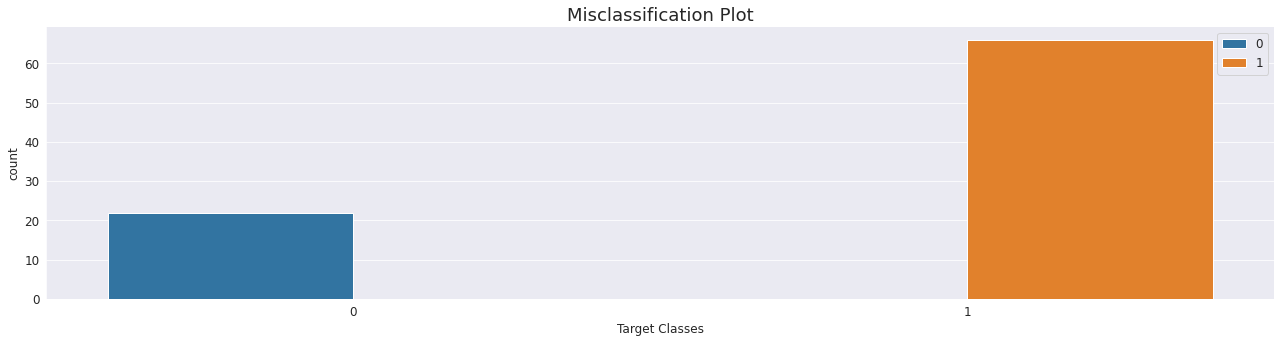

In [51]:
model.plot(y_test, y_pred)

In [52]:
def plot_classification_metrics(y_test, y_pred):
    """
    This function takes y_true and y_pred values to print the Classification metrics
    """
    matrix = confusion_matrix(y_test, y_pred)
    TP = matrix[0][0]
    FP = matrix[0][1]
    FN = matrix[1][0]
    TN = matrix[1][1]
    Accuracy = (TP + TN) / (TP + TN + FP + FN)
    print(f'Accuracy :  {round(Accuracy,4)}')
    Precision = (TP) / (TP + FP)
    print(f'Precision :  {round(Precision,4)}')
    Recall = (TP) / (TP + FN)
    print(f'Recall : {round(Recall,4)}')
    F1_Score = 2*(Precision*Recall/Precision+Recall)
    print(f'F1 Score : {round(F1_Score,4)}')
    Classification_Error = (FP+FN)/ (TP+FP+FN+TN)
    print(f'Classification Error : {round(Classification_Error,4)}')
    sensitivity =  TP/(TP+FN)
    print(f'Sensitivity / TPR: {round(sensitivity,4)}')
    specificity =  TN/(TP+FN)
    print(f'Specificity / TNR : {round(specificity,4)}')

In [53]:
y_train_pred = model.predict(X_train)
print('CLASSIFICATION METRICS, TRAIN DATA')
print(' '*10)
plot_classification_metrics(y_train, y_train_pred)

CLASSIFICATION METRICS, TRAIN DATA
          
Accuracy :  0.5923
Precision :  0.7668
Recall : 0.5738
F1 Score : 2.2953
Classification Error : 0.4077
Sensitivity / TPR: 0.5738
Specificity / TNR : 0.2987


In [54]:
print('CLASSIFICATION METRICS, TEST DATA')
print(' '*10)
plot_classification_metrics(y_test, y_pred)

CLASSIFICATION METRICS, TEST DATA
          
Accuracy :  0.6
Precision :  0.7864
Recall : 0.551
F1 Score : 2.2041
Classification Error : 0.4
Sensitivity / TPR: 0.551
Specificity / TNR : 0.3469


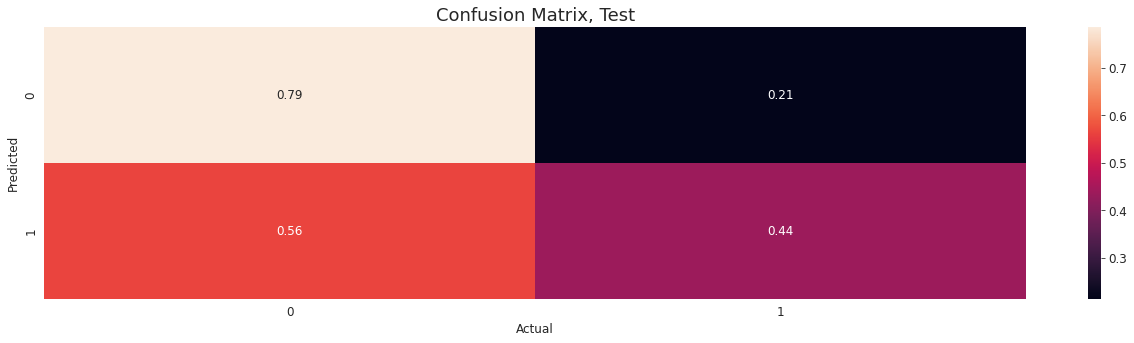

In [55]:
confusionmatrix = np.around(confusion_matrix(y_test, y_pred, normalize='true'),3)
sns.heatmap(confusionmatrix, annot=True)
plt.ylabel('Predicted')
plt.xlabel('Actual')
plt.title('Confusion Matrix, Test', fontsize=18)
plt.show()

In [56]:
print('Classification Report, Test Data')
print(classification_report(y_test, y_pred))

Classification Report, Test Data
              precision    recall  f1-score   support

           0       0.55      0.79      0.65       103
           1       0.70      0.44      0.54       117

    accuracy                           0.60       220
   macro avg       0.62      0.61      0.59       220
weighted avg       0.63      0.60      0.59       220



In [57]:
def plot_precision_recall(y_true, y_pred, train_or_test):
    '''
    y_true: Acutal values of the target
    y_pred: Predicted values of the target. Either predict_proba or decision_function
    line_show: Plot avergae values "precision" or "recall"
    train_or_test: Train Data or Test Data
    '''
    from sklearn.metrics import precision_recall_curve                
    
    precisions, recalls, thresholds = precision_recall_curve(y_true = y_true, probas_pred = y_pred)

    average_precision = np.mean(precisions)
    average_recall = np.mean(recalls)

    sns.lineplot(x = recalls, y = precisions, linewidth = 2, ci = None)
    plt.plot([0, 1], [average_precision, average_precision], 'r-')
    plt.plot([average_recall, average_recall], [0, 1], 'g-')
    plt.xlabel('Recall', fontsize = 14)
    plt.xticks(ticks = list(np.arange(0,1.1, 0.1)))
    plt.yticks(ticks = list(np.arange(0,1.1, 0.1)))
    plt.ylabel('Precision', fontsize = 14)
    plt.title(train_or_test, fontsize = 16)
    plt.legend(labels = ['Binary PR Curve', 'AP {:.2f}'.format(average_precision), 'AR {:.2f}'.format(average_recall)])
    plt.grid(True)
    plt.show()

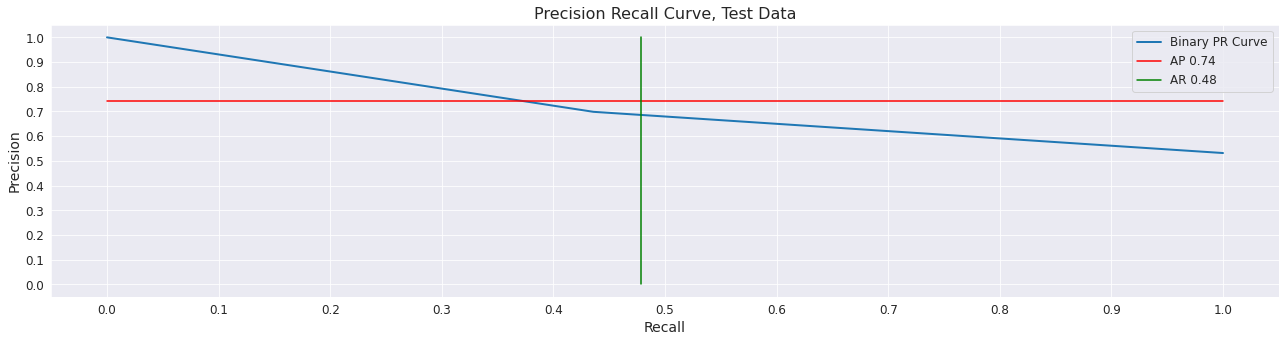

In [58]:
plt.figure(figsize = [22,5])
plot_precision_recall(y_true=y_test, y_pred=y_pred, train_or_test='Precision Recall Curve, Test Data')
plt.show()

Let's now plot a ROC Curve. 

- A ROC Curve is a graphical representation of the performance of a binary classifier system as its discrimination threshold is varied. 
- It is a way of measuring the trade-off between false positives and false negatives. 
- The ROC Curve is important because it allows one to visualize the performance of a classifier system and determine which trade-off between false positives and false negatives is optimal. 
- In addition, the ROC Curve can be used to compare different classifier systems and determine which one is better.

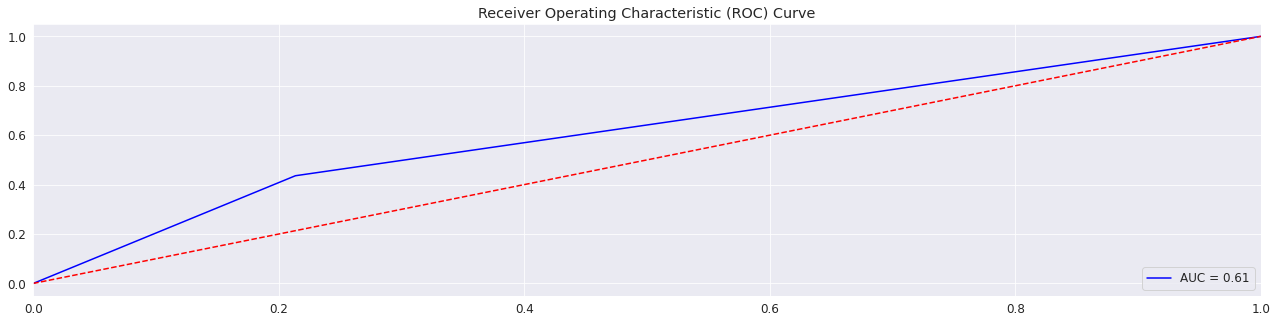

In [59]:
#obtain false positive rate, true positive rate and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

#calculate AUC
roc_auc = auc(fpr, tpr) 

#plot ROC curve
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc) 
plt.legend(loc = 'lower right') 
plt.plot([0, 1], [0, 1],'r--') 
plt.xlim([0, 1])
plt.show()

The AUC is a measure of the model's performance and ranges from 0 to 1, with higher values indicating better performance.

## Further Reading

1. https://www.analyticsvidhya.com/blog/2019/08/11-important-model-evaluation-error-metrics/
2. https://machinelearningmastery.com/why-one-hot-encode-data-in-machine-learning/
3. https://towardsdatascience.com/the-curse-of-dimensionality-50dc6e49aa1e
4. https://www.jeremyjordan.me/hyperparameter-tuning/
5. https://www.kaggle.com/code/bhatnagardaksh/digit-classification-anns-and-cnns